# Test Notebook

## This Notebok as of use of checking and using all functions for ests of both the functions and data

In [1]:
from constants import *
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from participant_gaze_data_manager import ParticipantGazeDataManager
import matplotlib.animation as animation
import os
import numpy as np
from scipy.ndimage import gaussian_filter
import cv2
import wave
from matplotlib.animation import FFMpegWriter
from constants import *
from moviepy.editor import VideoFileClip, AudioFileClip
from utils import prepare_image_and_gaze
from FixationHandler import FixationHandler, Fixation
from PanelSymbols import *
from RoiFinder import RoiFinder
from Trial import Trial, TrialManager, TrialManagerDebugger
from visualize_data import plot_gaze_over_img_by_time

In [2]:
from participant_gaze_data_manager import ParticipantGazeDataManager
import matplotlib.pyplot as plt
from Trial import Trial, TrialManager

p_name = "AG562"
task = "SDMT"
group = "pwMS"  # "HC" or "pwMS"
panel = "a3"
panel_path = f'/Volumes/ramot/Noam_M/Results/Behavior/panels_images/SDMT/combined_testable_{panel}.jpg'
data_path = "/Volumes/ramot/Noam_M/Results/Behavior"
output_path = f"/Volumes/ramot/rotation_students/Noam_M/visualized data/test_videos/{p_name}/"
# video_path = '/Volumes/ramot/rotation_students/Noam_M/visualized data/test_videos/participant_task_0_AG562.mp4'

participant_data = ParticipantGazeDataManager(p_name, data_path, task, group)
img = plt.imread(panel_path)

trial_maneger = TrialManager(participant_data, panel)


In [3]:
for trial in trial_maneger.trials:
    trigger = trial.triggering_symbol.value if trial.triggering_symbol else "None"
    print(f"\n🧩 Trial {trial.idx} — Triggering symbol: {trigger}")
    print("-" * 50)

    if not trial.searches:
        print("  No searches in this trial")
        continue

    for search in trial.searches:
        if not search.cleaned_sequence:
            print(f"  Search {search.idx}: No clean sequence")
            continue

        values_str = "->".join(
            str(s.value) if s is not None else "None"
            for s in search.cleaned_sequence.values()
        )
        print(f"  Search {search.idx}: {values_str}")


🧩 Trial 3 — Triggering symbol: 5
--------------------------------------------------
  Search 3: 6->5

🧩 Trial 4 — Triggering symbol: 3
--------------------------------------------------
  Search 4: 4->3->4

🧩 Trial 5 — Triggering symbol: 6
--------------------------------------------------
  Search 5: 3->6

🧩 Trial 6 — Triggering symbol: 8
--------------------------------------------------
  Search 6: 4->2->8

🧩 Trial 7 — Triggering symbol: 4
--------------------------------------------------
  Search 7: 5->7->2->8->1
  Search 8: 7->4

🧩 Trial 8 — Triggering symbol: 6
--------------------------------------------------
  Search 9: 4->6->7

🧩 Trial 9 — Triggering symbol: 1
--------------------------------------------------
  Search 10: 5->8->1->7

🧩 Trial 10 — Triggering symbol: 2
--------------------------------------------------
  Search 11: 4->2->6

🧩 Trial 11 — Triggering symbol: 4
--------------------------------------------------
  Search 12: 4

🧩 Trial 12 — Triggering symbol: 3
-

In [8]:
for trial in trial_maneger.trials:
    trigger = trial.triggering_symbol.value if trial.triggering_symbol else "None"
    print(f"\n🧩 Trial {trial.idx} — Triggering symbol: {trigger}")
    print("-" * 50)

    if not trial.searches:
        print("  No searches in this trial")
        continue

    for search in trial.searches:
        if not search.sequence:
            print(f"  Search {search.idx}: No sequence")
            continue

        values_str = "->".join(
            str(s.value) if s is not None else "None"
            for s in search.sequence.values()
        )
        print(f"  Search {search.idx}: {values_str}")


🧩 Trial 3 — Triggering symbol: 5
--------------------------------------------------
  Search 3: 6->5->5

🧩 Trial 4 — Triggering symbol: 3
--------------------------------------------------
  Search 4: 4->3->3->4

🧩 Trial 5 — Triggering symbol: 6
--------------------------------------------------
  Search 5: 3->6->6->6

🧩 Trial 6 — Triggering symbol: 8
--------------------------------------------------
  Search 6: 4->2->2->8->8

🧩 Trial 7 — Triggering symbol: 4
--------------------------------------------------
  Search 7: 5->7->2->8->1
  Search 8: 7->4->4

🧩 Trial 8 — Triggering symbol: 6
--------------------------------------------------
  Search 9: 4->6->6->7

🧩 Trial 9 — Triggering symbol: 1
--------------------------------------------------
  Search 10: 5->8->1->7

🧩 Trial 10 — Triggering symbol: 2
--------------------------------------------------
  Search 11: 4->2->6

🧩 Trial 11 — Triggering symbol: 4
--------------------------------------------------
  Search 12: 4->4->4

🧩 Tri

Error processing YS875 panel 0: Too many NaN values in panel 2 for dominant eye 'l'
Error processing YS875 panel i1: Too many NaN values in panel 2 for dominant eye 'l'
Error processing YS875 panel l4: Too many NaN values in panel 2 for dominant eye 'l'
Error processing YS875 panel a3: Too many NaN values in panel 2 for dominant eye 'l'
Error processing YS875 panel a5: Too many NaN values in panel 2 for dominant eye 'l'
Error processing YS875 panel l3: Too many NaN values in panel 2 for dominant eye 'l'
Plot saved successfully as: /Volumes/ramot/Noam_M/preliminary_results/AG562/0/symbols_per_trial_subject_AG562_panel_0.png
Plot saved successfully as: /Volumes/ramot/Noam_M/preliminary_results/AG562/i1/symbols_per_trial_subject_AG562_panel_i1.png
Plot saved successfully as: /Volumes/ramot/Noam_M/preliminary_results/AG562/l4/symbols_per_trial_subject_AG562_panel_l4.png
Plot saved successfully as: /Volumes/ramot/Noam_M/preliminary_results/AG562/a3/symbols_per_trial_subject_AG562_panel_a3.p

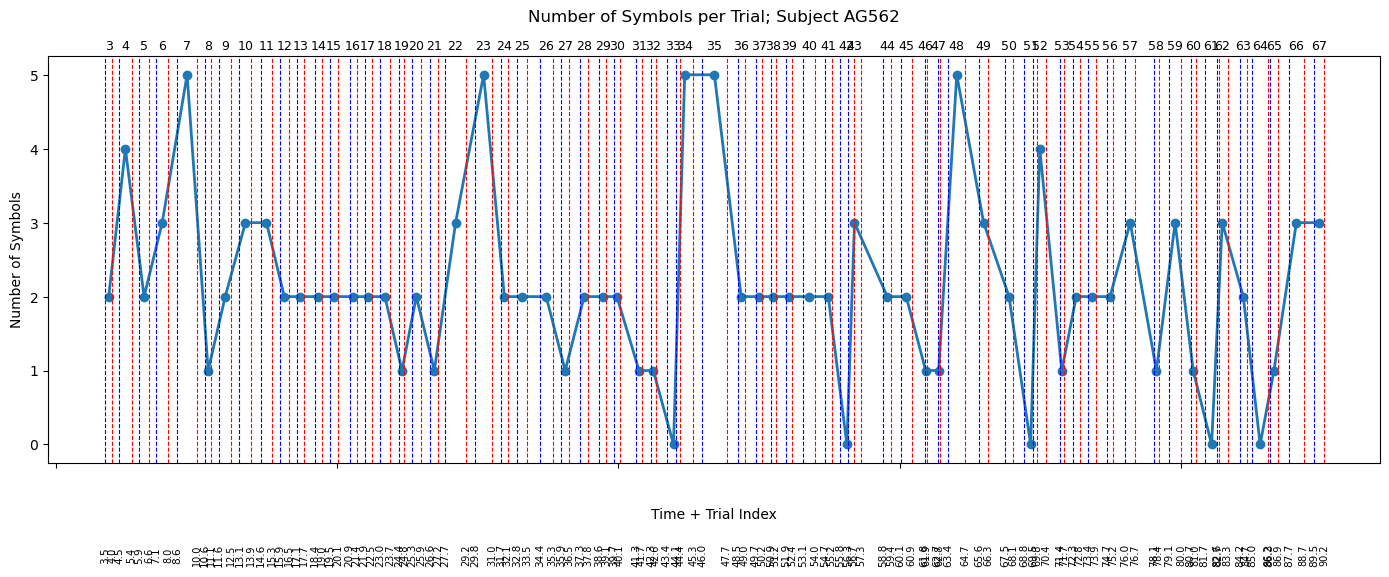

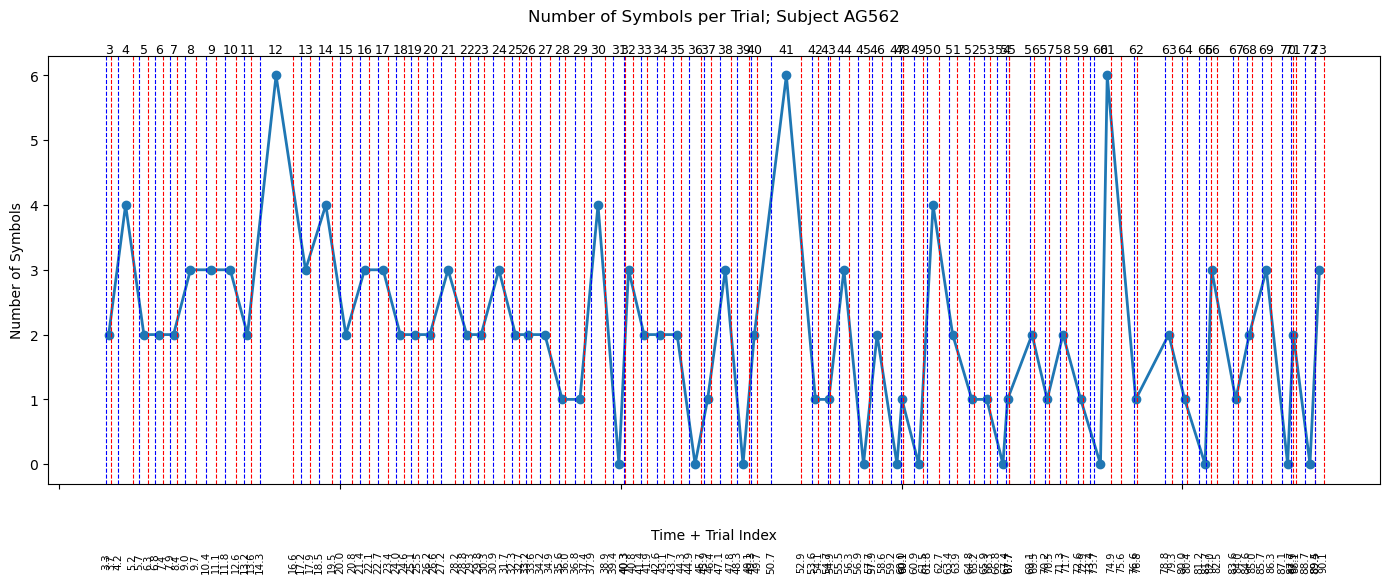

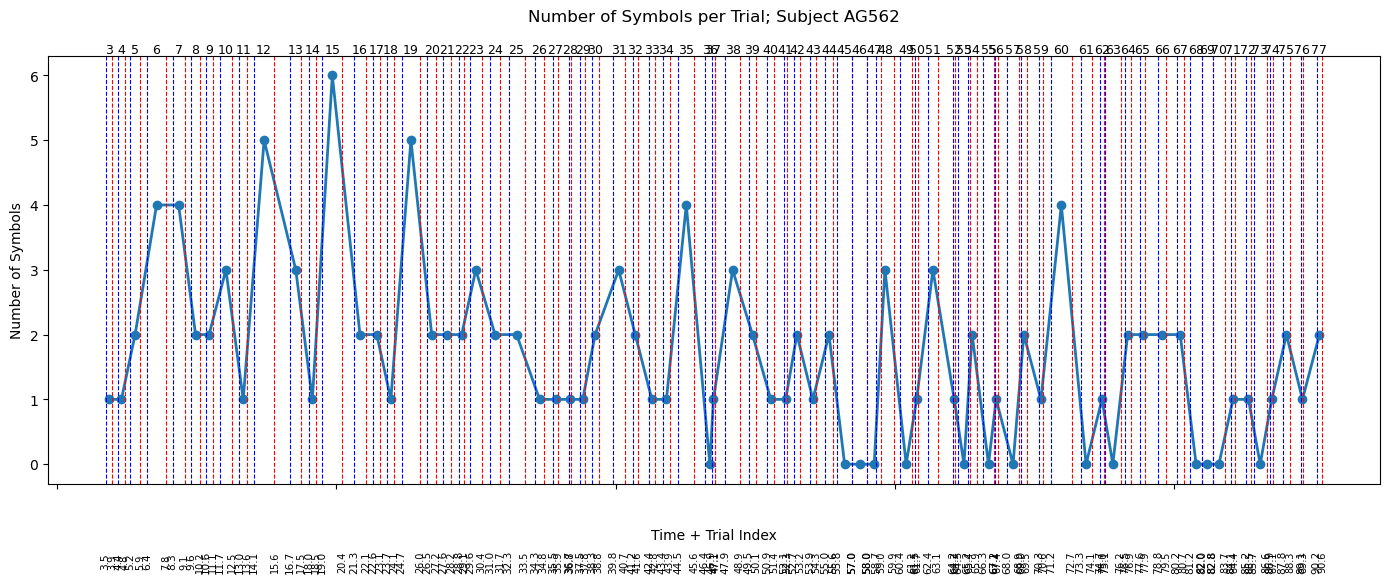

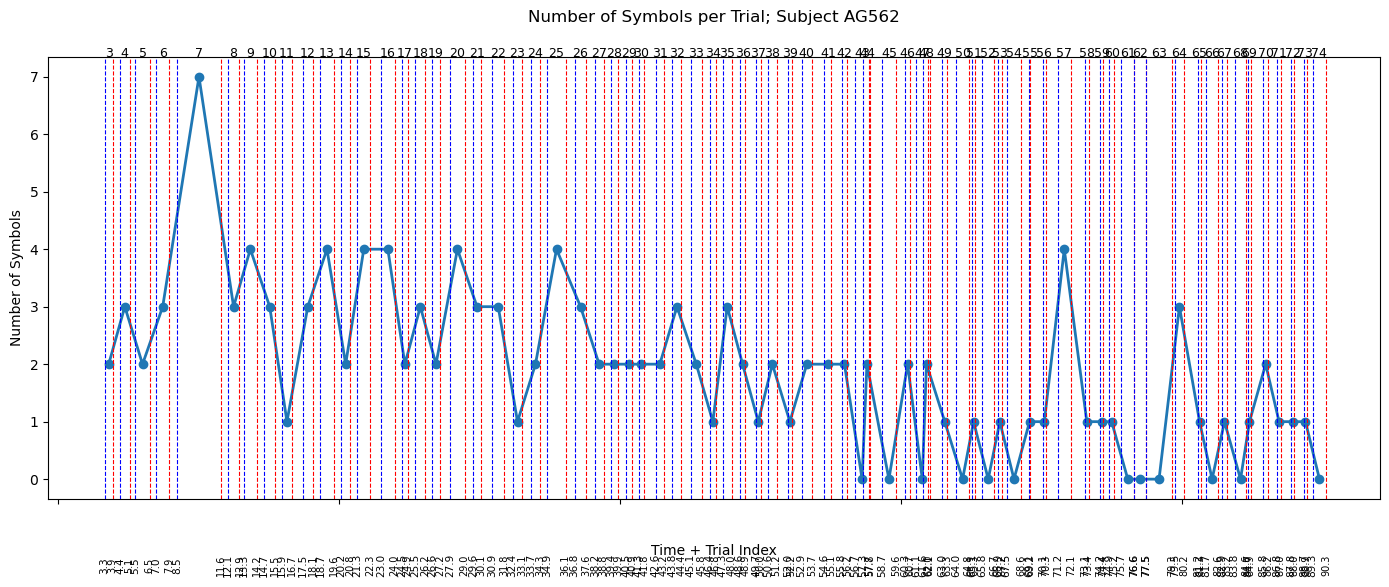

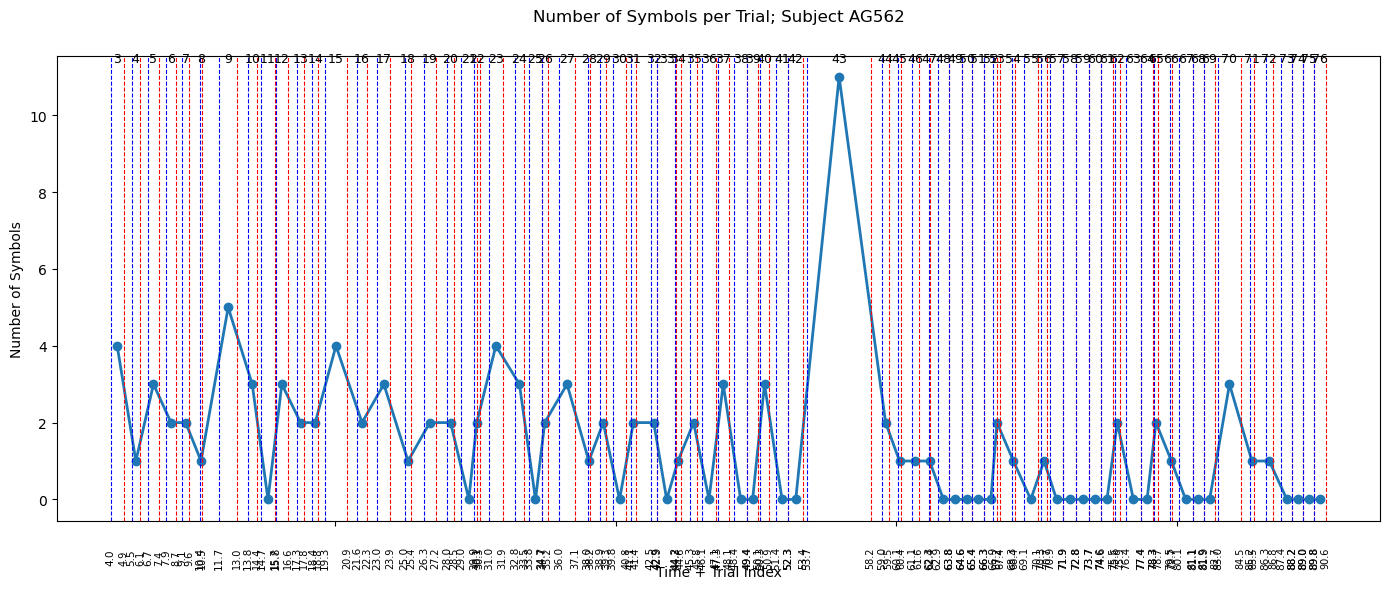

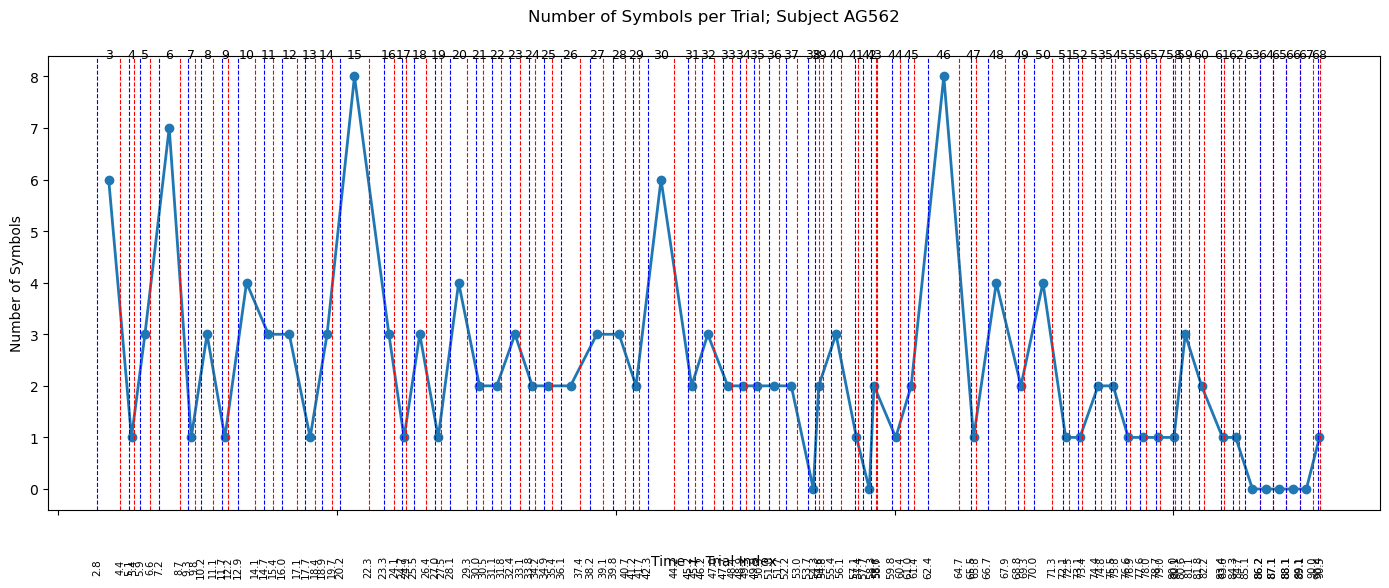

In [ ]:
from MCAnalyzer import MCAnalyzer
from participant_gaze_data_manager import ParticipantGazeDataManager
from Trial import TrialManager

main_path = "/Volumes/ramot/Noam_M/Results/Behavior"

subjects = {"pwMS": ["ZC673", "AG562"],
            "HC": ["NN111"]}

panels = ["0", "i1", "l4", "a3", "a5", "l3"]

for group in subjects.keys():
    for p_name in subjects[group]:
        for panel in panels:
            try:
                output_path = f"/Volumes/ramot/Noam_M/preliminary_results/{p_name}/{panel}"
                participant_data = ParticipantGazeDataManager(p_name, main_path , "SDMT", group)
                trial_maneger = TrialManager(participant_data, panel)
                trial_maneger.num_symbols_per_trial(output_path=output_path)
                # mc_analyzer = MCAnalyzer(trial_maneger.trials)
                # mc_analyzer.create_transition_probabilities_heatmap(p_name, panel, output_path)
            except Exception as e:
                print(f"Error processing {p_name} panel {panel}: {e}")

In [ ]:
# two ways to get time intervals from the end of one trial to the start of another
time_intervals = trial_maneger.get_inter_trial_times([(46, 48), (33, 35)])
print(time_intervals)

# or get the duration of a specific trial
time_intervals = [trial_maneger.get_trial_duration(18)]
print(time_intervals)

In [7]:
annotated_data = participant_data.annotate_gaze_events('threshold_based', panel)
img_resized, annotated_data = prepare_image_and_gaze(img, annotated_data)

In [ ]:
from visualize_data import plot_gaze_over_img_by_time

plot_gaze_over_img_by_time(annotated_data, img_resized, time_intervals)

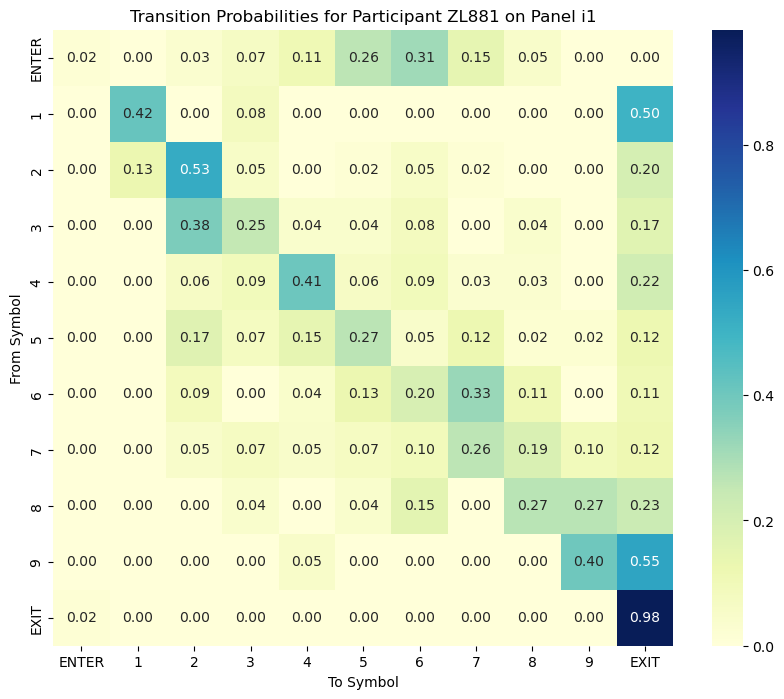

In [9]:
from MCAnalyzer import MCAnalyzer
from participant_gaze_data_manager import ParticipantGazeDataManager
from Trial import TrialManager
import matplotlib.pyplot as plt

# "0": PANEL_0,
# "i1": PANEL_i1,
# "l4": PANEL_l4,
# "l3": PANEL_l3,
# "a3": PANEL_a3,
# "a5": PANEL_a5,
p_name = "ZL881"
task = "SDMT"
group = "pwMS"  # "HC" or "pwMS"
panel = "i1"
data_path = "/Volumes/ramot/Noam_M/Results/Behavior"

participant_data = ParticipantGazeDataManager(p_name, data_path, task, group)

trial_maneger = TrialManager(participant_data, panel)

mc_analyzer = MCAnalyzer(trial_maneger.trials)

p = mc_analyzer.get_transition_probabilities(clean = False)

# heatmap for p table
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(p, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title(f"Transition Probabilities for Participant {p_name} on Panel {panel}")
plt.xlabel("To Symbol")
plt.ylabel("From Symbol")
plt.show()


No searches with sequences found in trial 27: []
No searches with sequences found in trial 44: []
No searches with sequences found in trial 50: []
No searches with sequences found in trial 52: []
No searches with sequences found in trial 55: []
No searches with sequences found in trial 56: []


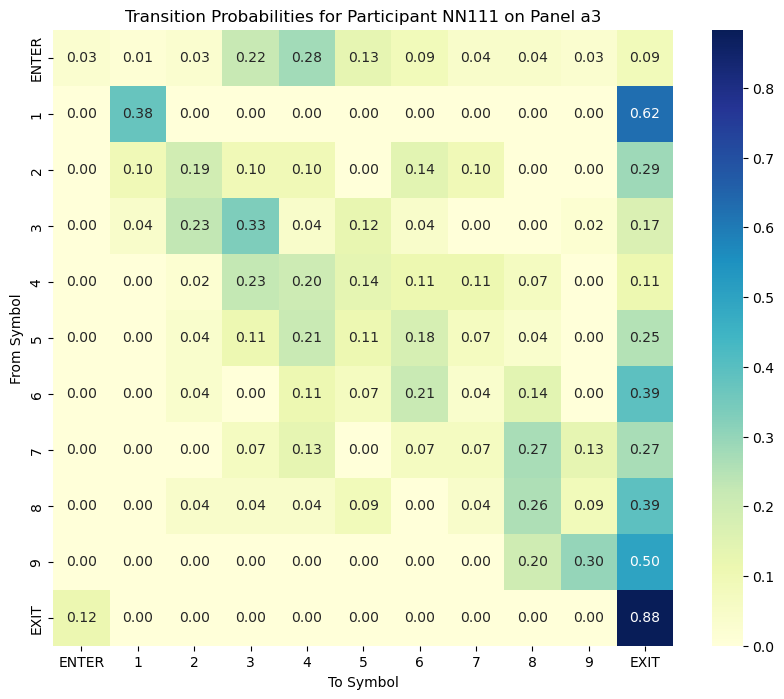

In [ ]:
from MCAnalyzer import MCAnalyzer
from participant_gaze_data_manager import ParticipantGazeDataManager
from Trial import TrialManager
import matplotlib.pyplot as plt
data_path = "/Volumes/ramot/Noam_M/Results/Behavior"
task = "SDMT"

p_name = ""
panel = "a3"
participant_data = ParticipantGazeDataManager(p_name, data_path, task, "HC")

trial_maneger = TrialManager(participant_data, panel)
mc_analyzer = MCAnalyzer(trial_maneger.trials)

p = mc_analyzer.get_transition_probabilities()

# heatmap for p table
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(p, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title(f"Transition Probabilities for Participant {p_name} on Panel {panel}")
plt.xlabel("To Symbol")
plt.ylabel("From Symbol")
plt.show()


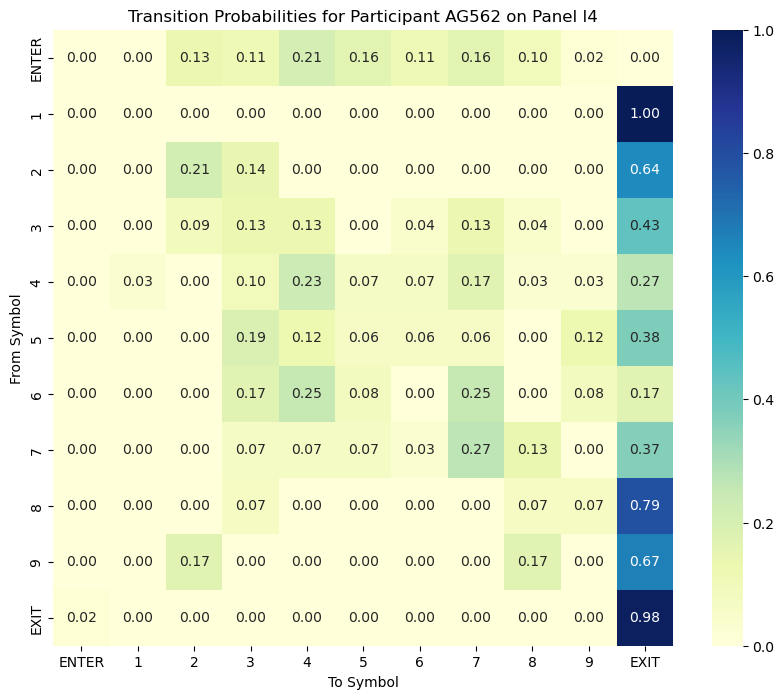

In [3]:

panel = "l4"


participant_data = ParticipantGazeDataManager(p_name, data_path, task, group)

panel_path = f'/Volumes/ramot/Noam_M/Results/Behavior/panels_images/SDMT/combined_testable_{panel}.jpg'
img = plt.imread(panel_path)

trial_maneger = TrialManager(participant_data, panel)

mc_analyzer = MCAnalyzer(trial_maneger.trials)

p = mc_analyzer.get_transition_probabilities()

# heatmap for p table
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(p, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title(f"Transition Probabilities for Participant {p_name} on Panel {panel}")
plt.xlabel("To Symbol")
plt.ylabel("From Symbol")
plt.show()

In [ ]:
stationary_prob =  mc_analyzer.stationary_distribution(nodes_to_drop=["ENTER", "EXIT"])
# states = ["ENTER", "1", "2", "3", "4", "5", "6", "7", "8", "9", "EXIT"]
states = ["1", "2", "3", "4", "5", "6", "7", "8", "9"]

# for i in range(len(states)):
#     print(f"state {states[i]} happens in prob: {round(stationary_prob[i], 3)} when going to infinity")

#plot all states provbability in a bar graph
plt.bar(states, stationary_prob)
plt.xlabel("States")
plt.ylabel("Stationary Probability")
plt.title(f"Stationary Distribution for Participant {p_name} on Panel {panel}")
plt.show()


In [ ]:
mc_analyzer.plot_transition_graph_no_enter_exit()

In [ ]:
mc_analyzer.plot_transition_graph()

In [ ]:
mc_analyzer.most_probable_paths(n=5, max_length=10)

In [ ]:
# def plot_transition_graph_no_enter_exit(self, threshold: float = 1/9, node_margin: float = 0.15):
    """Plot transition graph (without ENTER/EXIT) with probability-weighted, properly spaced arrows."""

    # Get probability matrix excluding ENTER and EXIT
    df = self.get_transition_probabilities().copy()
    df = df.drop(index=['ENTER'], columns=['EXIT'], errors='ignore')

    # Build directed graph
    G = nx.DiGraph()
    for a in df.index:
        for b in df.columns:
            prob = df.loc[a, b]
            if prob > threshold:
                G.add_edge(a, b, weight=prob)

    # Layout: increase k for more spacing
    pos = nx.spring_layout(G, k=1.5, seed=42)

    # Draw nodes
    nx.draw_networkx_nodes(
        G, pos,
        node_color='skyblue',
        node_size=900,
        alpha=0.7,
        edgecolors='k'
    )

    # Separate edges
    curved_edges, straight_edges, self_loops = [], [], []
    for (u, v) in G.edges():
        if u == v:
            self_loops.append((u, v))
        elif (v, u) in G.edges():
            curved_edges.append((u, v))
        else:
            straight_edges.append((u, v))

    # Draw straight arrows (unidirectional)
    nx.draw_networkx_edges(
        G, pos,
        edgelist=straight_edges,
        arrowstyle='-|>',
        arrowsize=16,
        edge_color='gray',
        width=[G[u][v]['weight'] * 8 for u, v in straight_edges],
        connectionstyle=f'arc3,rad=0'
    )

    # Draw curved arrows for bidirectional edges
    nx.draw_networkx_edges(
        G, pos,
        edgelist=curved_edges,
        arrowstyle='-|>',
        arrowsize=16,
        edge_color='gray',
        width=[G[u][v]['weight'] * 8 for u, v in curved_edges],
        connectionstyle=f'arc3,rad=0.25'
    )

    # Draw self-loops as circular arrows
    for u, v in self_loops:
        x, y = pos[u]
        loop_radius = 0.08
        loop = plt.Circle((x, y + 0.15), loop_radius, color='gray', fill=False, lw=G[u][v]['weight'] * 5)
        plt.gca().add_patch(loop)
        # Add arrowhead to loop
        # plt.arrow(x, y + 0.13, 0, -0.0001, head_width=0.05, head_length=0.02, fc='gray', ec='gray')

        # Add label for self-loop
        plt.text(x, y + 0.25, f"{G[u][v]['weight']:.3f}",
                fontsize=8, ha='center', va='center',
                bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=0.3))

    # Draw node labels
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

    # Draw probability labels for non-self edges
    for (u, v, d) in G.edges(data=True):
        if u == v:
            continue
        prob = d['weight']
        x1, y1 = pos[u]
        x2, y2 = pos[v]

        # shorten both ends to avoid overlap with nodes
        dx, dy = x2 - x1, y2 - y1
        new_x1 = x1 + node_margin * dx
        new_y1 = y1 + node_margin * dy
        new_x2 = x2 - node_margin * dx
        new_y2 = y2 - node_margin * dy
        mid_x = (new_x1 + new_x2) / 2
        mid_y = (new_y1 + new_y2) / 2

        angle = np.degrees(np.arctan2(dy, dx))
        plt.text(mid_x, mid_y, f"{prob:.3f}",
                fontsize=8, color='black',
                ha='center', va='center',
                rotation=angle,
                bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=0.3))

    plt.axis('off')
    plt.title("Transition Graph (probabilities > 1/9, ENTER/EXIT removed)",
            fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [ ]:
# print one search sequence and cleaned sequence
for trial in trial_maneger.trials:
    trigger = trial.triggering_symbol.value if trial.triggering_symbol else "None"
    print(f"\n🧩 Trial {trial.idx} — Triggering symbol: {trigger}")
    print("-" * 50)

    if not trial.searches:
        print("  No searches in this trial")
        continue

    for search in trial.searches:
        if not search.sequence:
            print(f"  Search {search.idx}: No sequence")
            continue

        values_str = "->".join(
            str(s.value) if s is not None else "None"
            for s in search.sequence.values()
        )
        print(f"  Search {search.idx}: {values_str}")

        if not search.cleaned_sequence:
            print(f"  Search {search.idx}: No clean sequence")
            continue

        cleaned_values_str = "->".join(
            str(s.value) if s is not None else "None"
            for s in search.cleaned_sequence
        )
        print(f"  Search {search.idx} Cleaned: {cleaned_values_str}")